# Sequential Analysis


In [ ]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_npy_file, create_grouped_npy_files, create_npy_file_truncated

no_instructions = 5000


In [2]:
sequential_registers = ["r0", "r1", "r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9", "r10", "r11", "r12", "sp", "lr"]
sequential_trace_dir = "output_decapsulation_sequential_TRIM"
result_dir = "Results_decapsulation_sequential"
no_instructions = 500
reset_folder(result_dir)

reset_result_dir = False
if reset_result_dir:
    reset_folder(result_dir)
os.makedirs(result_dir, exist_ok=True)

create_npy_file(f"{result_dir}/RESULTS_HW", sequential_trace_dir, "HW", sequential_registers)
create_npy_file(f"{result_dir}/RESULTS_HD", sequential_trace_dir, "HD", sequential_registers)


Creating simulation traces model.... HW
Trace 0 has been converted
The last trace that was captured is Trace 2
Finished creating Results_decapsulation_sequential/RESULTS_HW.npy, shape = (2, 29237)
Creating simulation traces model.... HD
Trace 0 has been converted
The last trace that was captured is Trace 2
Finished creating Results_decapsulation_sequential/RESULTS_HD.npy, shape = (2, 29236)


In [3]:
filename_hw = f"{result_dir}/RESULTS_HW.npy"
filename_hd = f"{result_dir}/RESULTS_HD.npy"

data_HW = np.load(filename_hw)
data_HD = np.load(filename_hd)

information(data_HW)
information(data_HD)


The shape of the data is: (2, 29237)
The type of the data is: float64
The first 2 traces are: [[ 80.  82.  83. ... 139. 129. 130.]
 [ 80.  82.  83. ... 145. 135. 136.]]
If there are any NaN values: False
The shape of the data is: (2, 29236)
The type of the data is: float64
The first 2 traces are: [[ 2.  1.  9. ...  0. 28.  7.]
 [ 2.  1.  9. ...  0. 28.  7.]]
If there are any NaN values: False


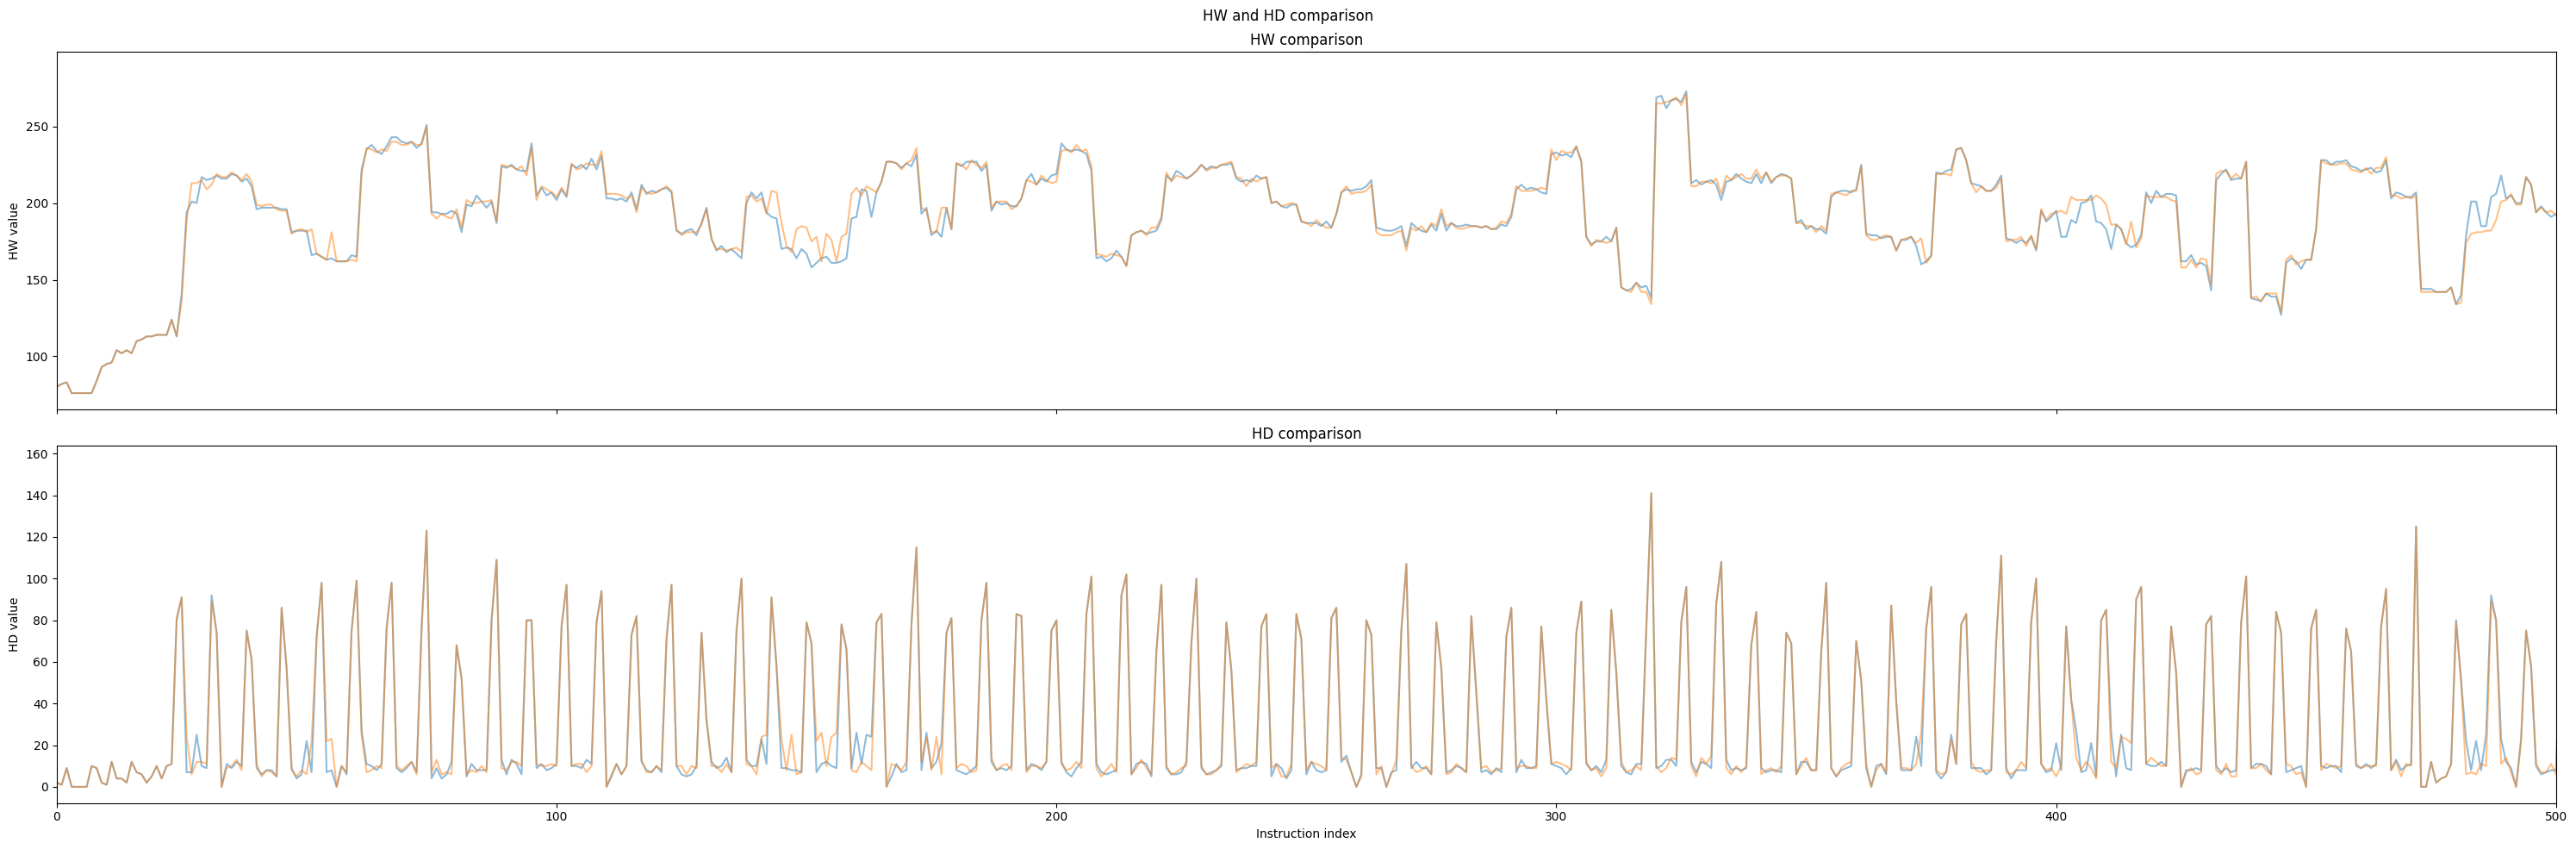

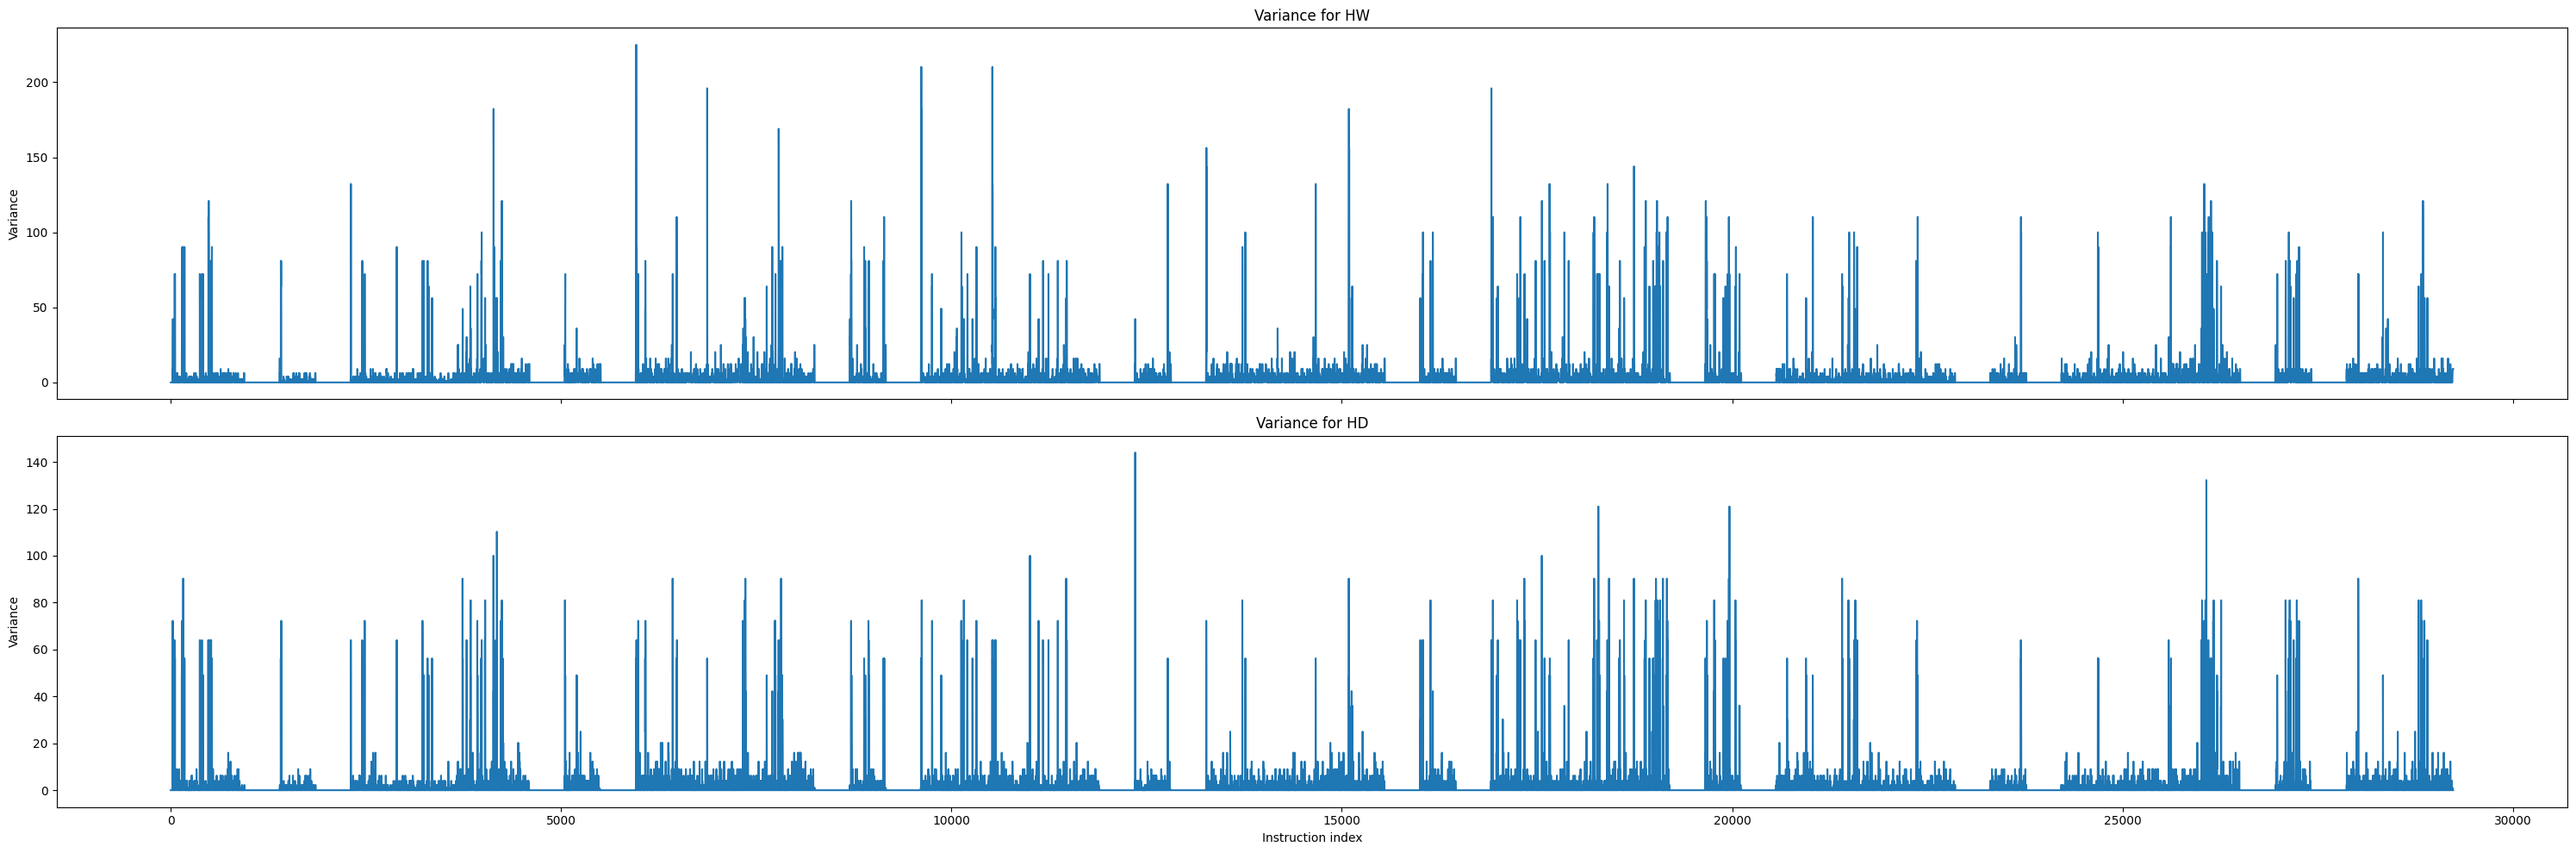

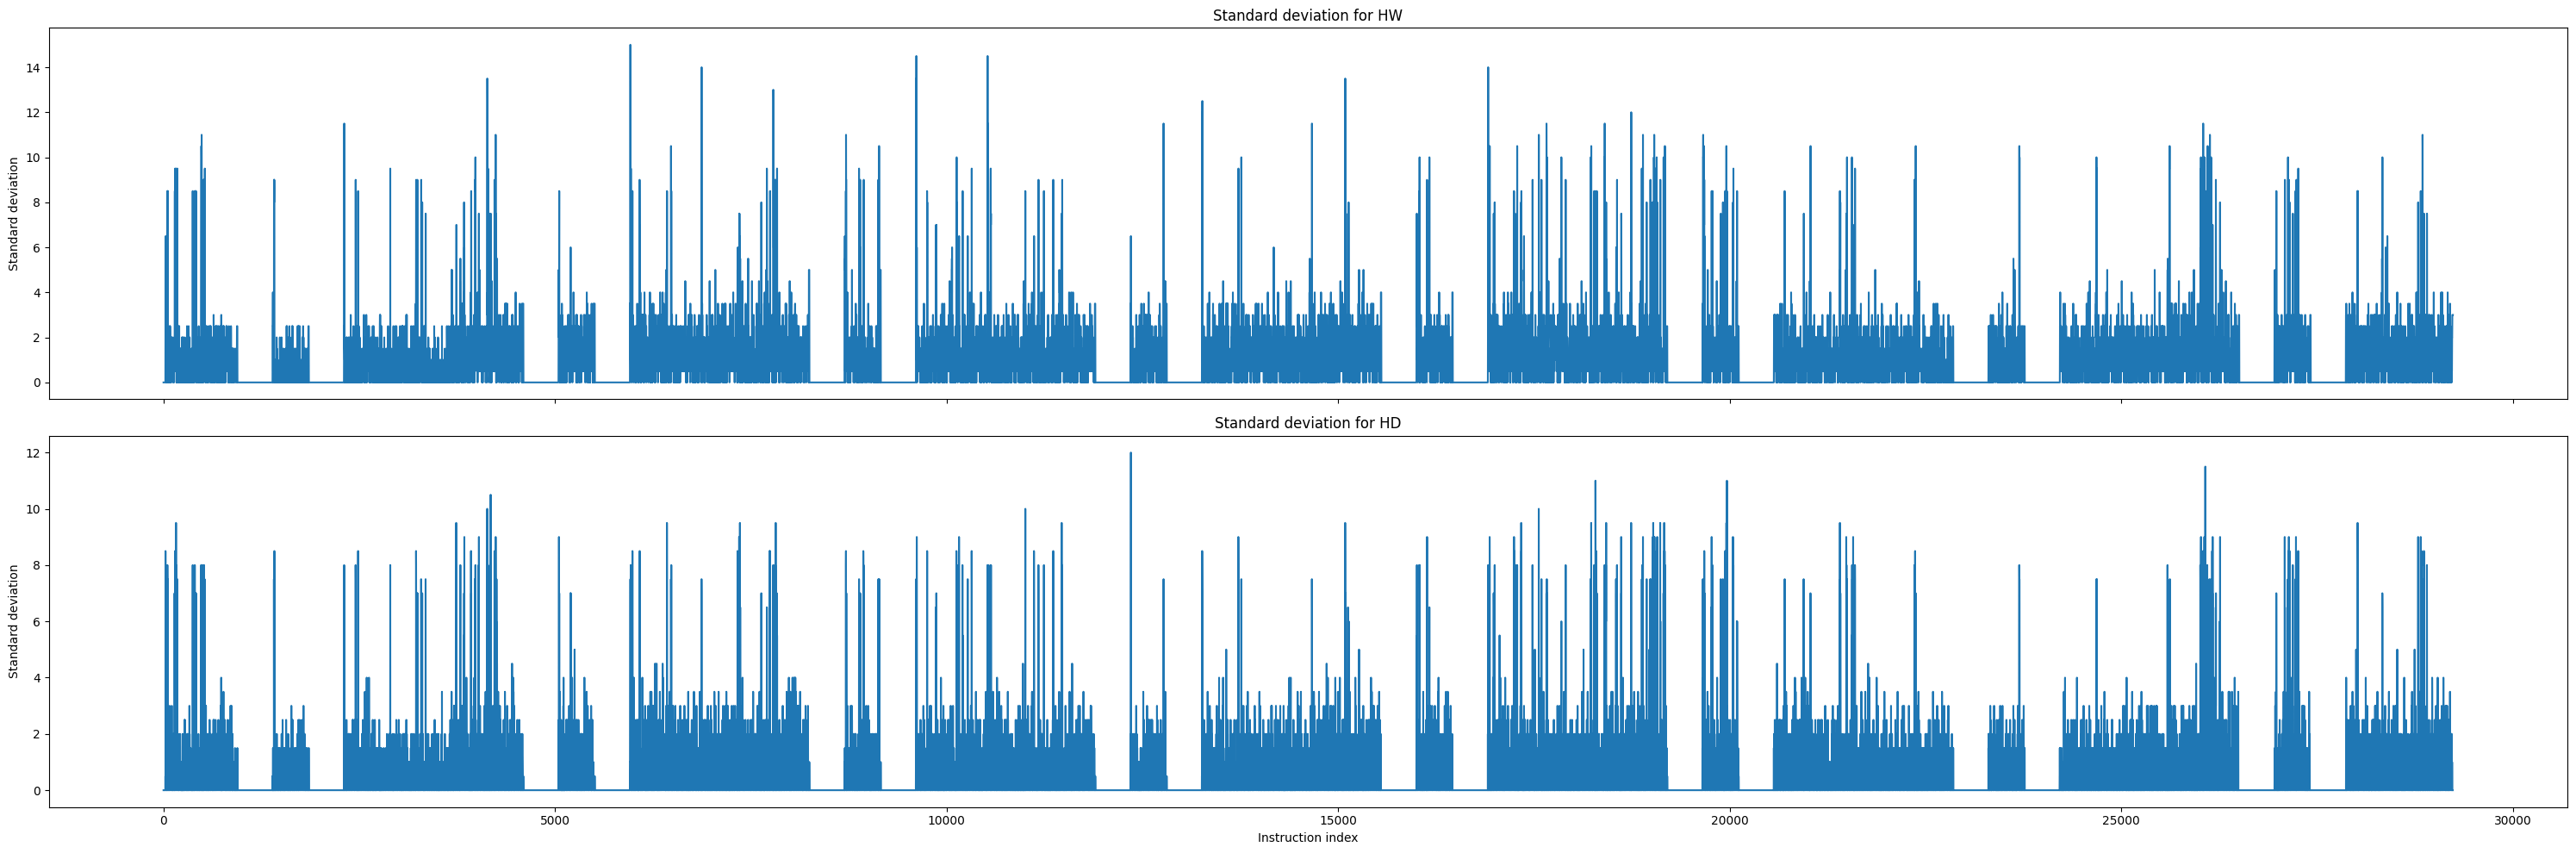

In [4]:
plot_hw_hd_comparison(data_HW, data_HD, save_path=os.path.join(result_dir, "traces_plot.png"), no_instructions=no_instructions)
plot_variance_and_std(data_HW, data_HD, result_dir, no_instructions=no_instructions)


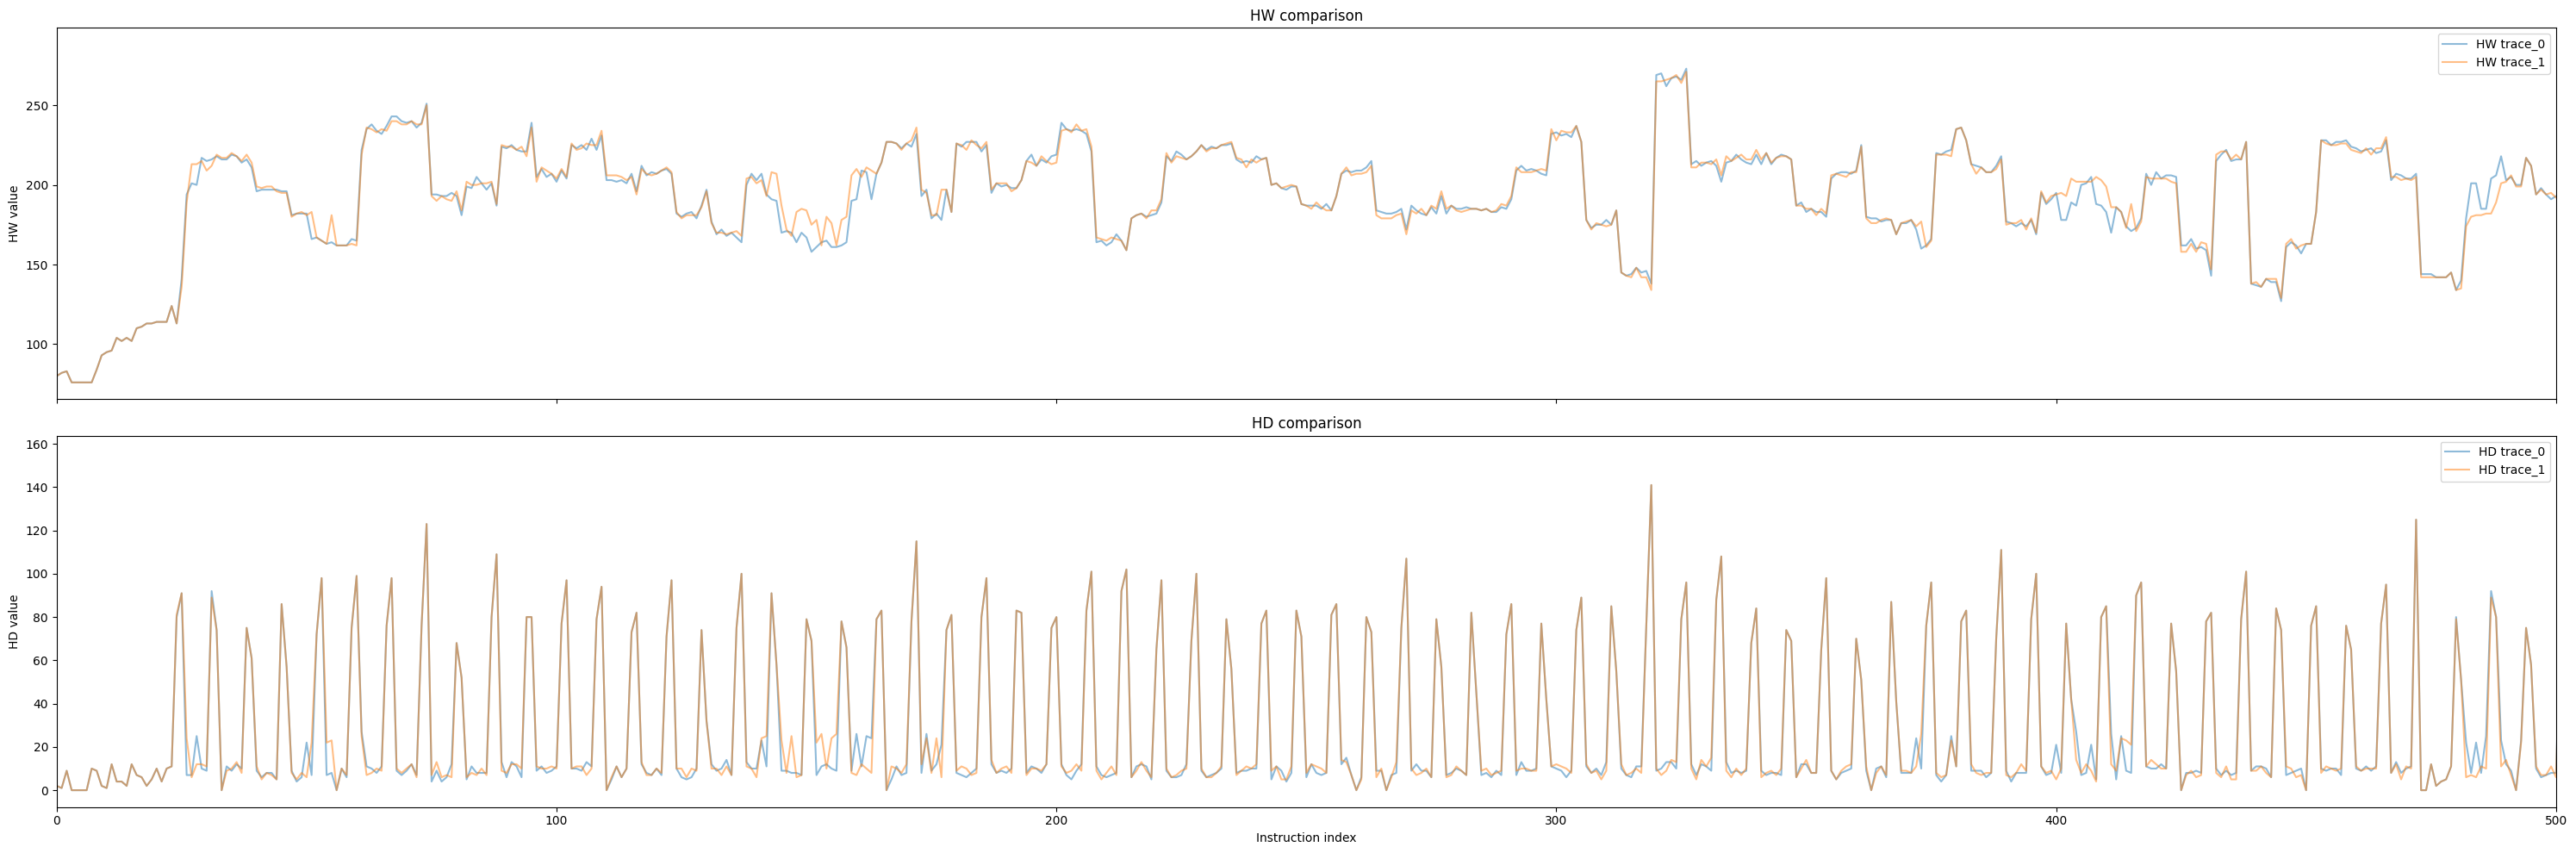

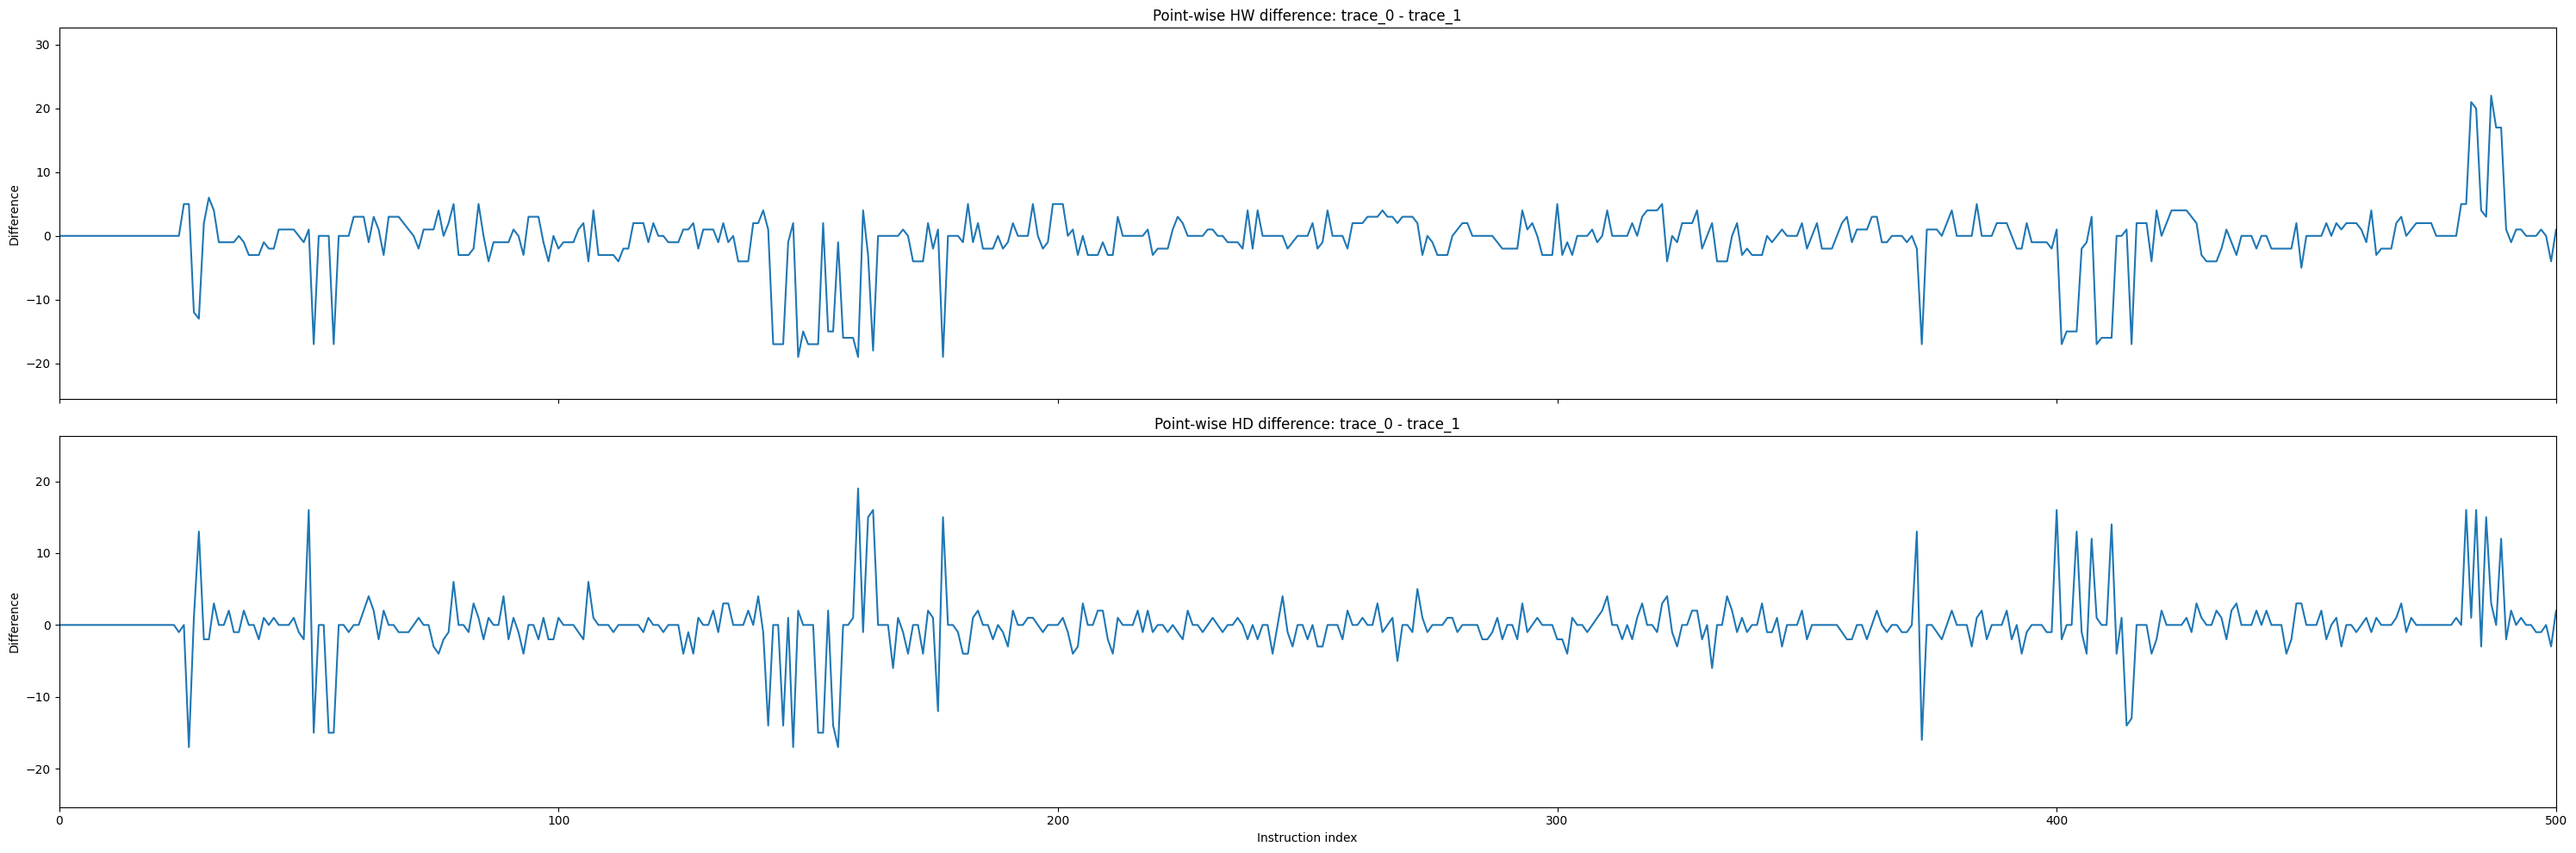

Correlation HW (0,1) = 0.9915
Correlation HD (0,1) = 0.9969


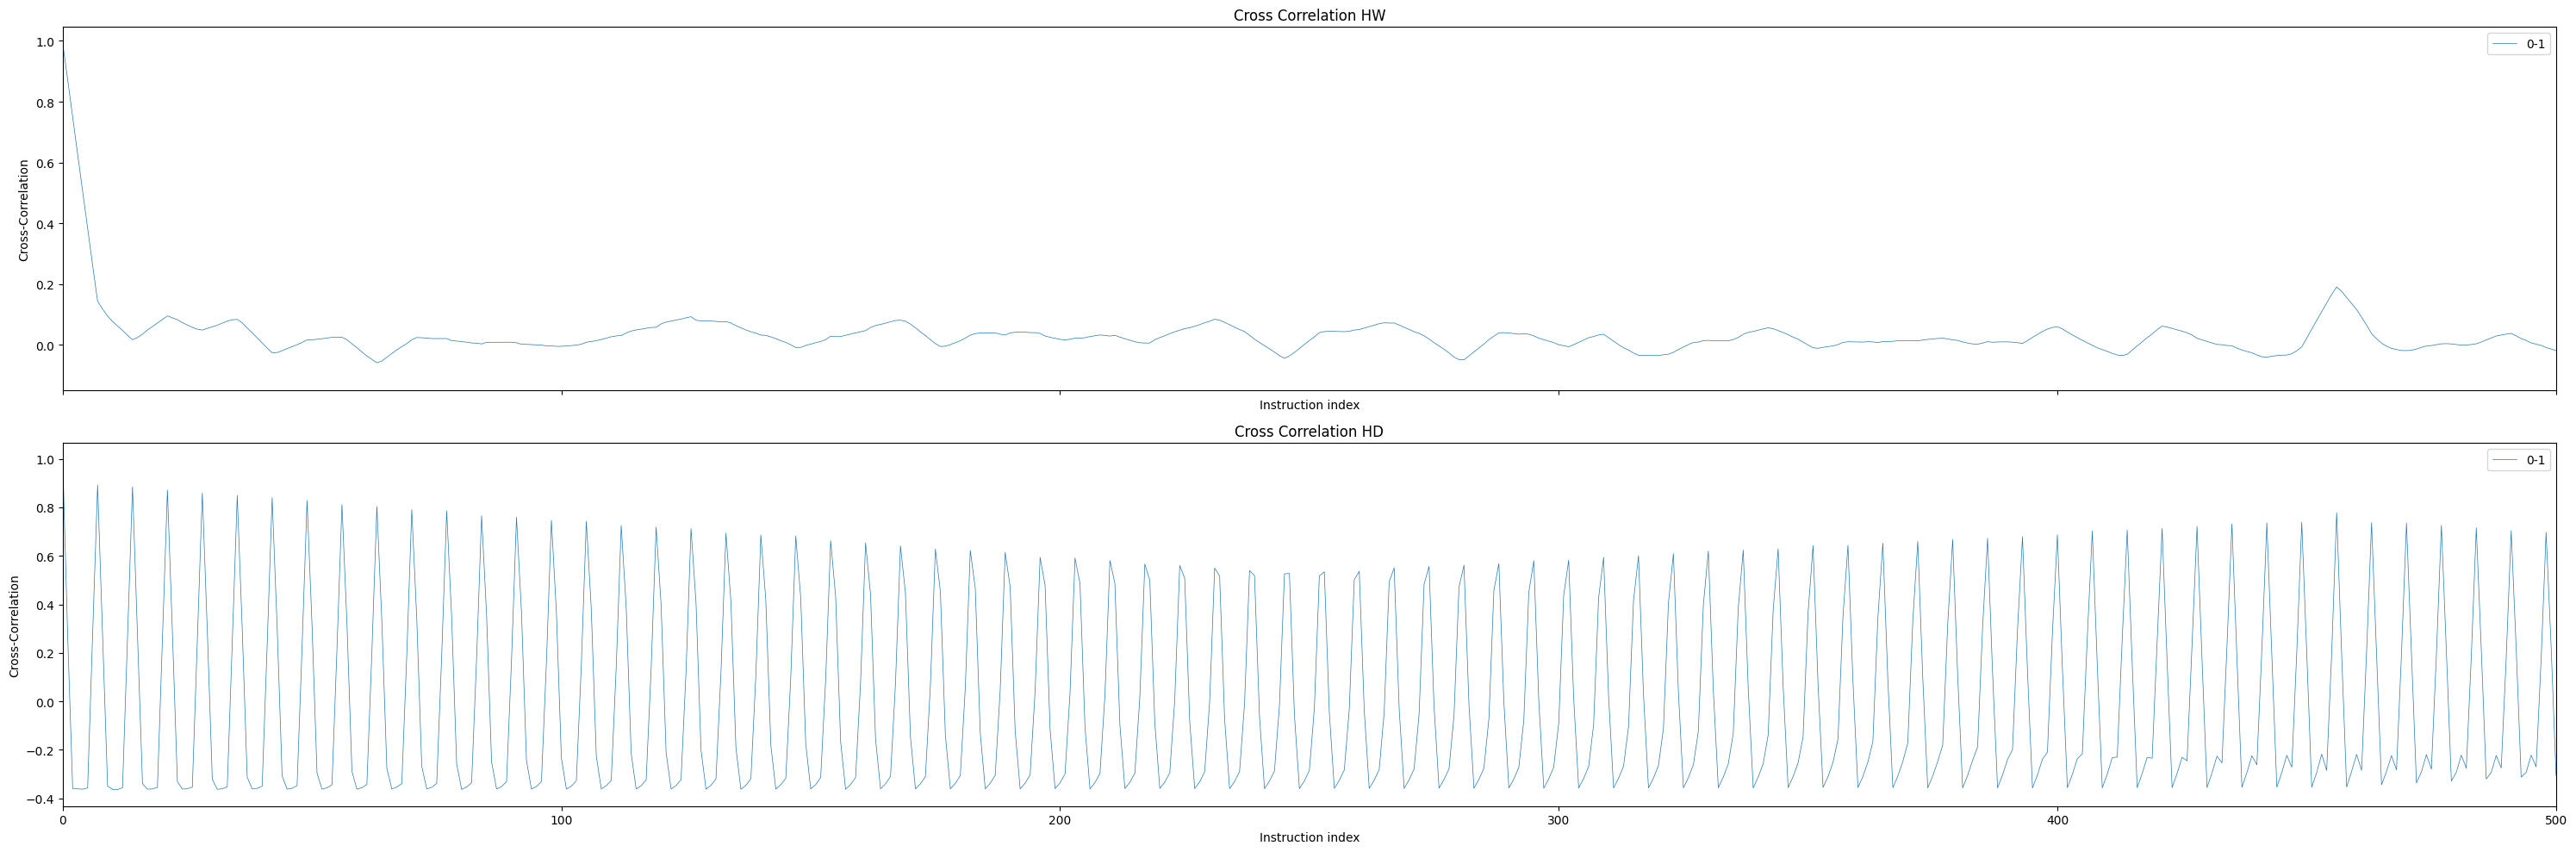

In [5]:
index1 = 0
index2 = 1
plot_hw_hd_two_traces(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "hw_and_hd_traces_comparison.png"), no_instructions=no_instructions)
plot_hw_hd_difference(data_HW, data_HD, index1, index2, save_path=os.path.join(result_dir, "pointwise_difference.png"), no_instructions=no_instructions)
plot_cross_correlation_hw_hd(data_HW, data_HD, [(index1, index2)], save_path=os.path.join(result_dir, f"correlation_between_{index1}_vs_{index2}.png"), no_instructions=no_instructions)
